In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Sequential Data
Data ordered in time or space
Order of data points has DEPENDENCIES between them

* Time series as an big example
* But also
* Text, Audio Waeves -> LARCH LANGUAGE MODELS

# Preparing Time Series/Sequence Data

## Train-Test-Split and Lookahead Bias
If we put data from future, model would have information about future.

Solution: Split by time

## Creating Windows

```
[0,1,2] → 3
[1,2,3] → 4
[2,3,4] → 5
...
[6,7,8] → 9
```

**Sequence length**: number of data points in one training example

* Our dataset has recordings of electricity consumption for every 15 minute.
* GOAL: Predicting the consumption for the 15 minute, after 24 HOURS (our window).
    * 24 Hours has 60/15=4, 24 * 4 = 96 15 minutes inside it
    * So our dataset will contain 96 elements


Example output shape:

X_train = (34944,96)
    * 34,944 windows, each containing 96 timesteps.

Y_train = 34,944

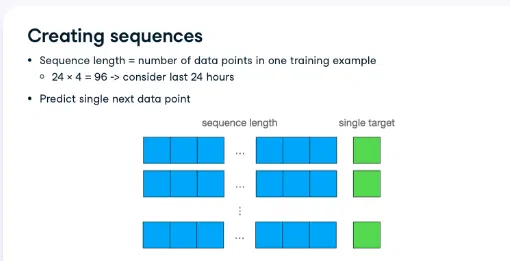

In [ ]:
def create_sequences(df, seq_legth):
    X_list = []
    y_list=  []

    for i in range(len(df)-seq_legth): #FOR EVERY POSSIBLE WINDOW
        X = df.iloc[i:(i+seq_legth), 1]
            #iloc: locating integer, []
            # ....,1 is dataframe specific, to choose just second column
            #from current i to, !!EXCLUSIVE!!: i+sequence_length

        y= df.iloc[i+seq_legth, 1]

        X_list.append(X)
        y_list.append(y)

    return np.array(X_list), np.array(y_list)



#Reccurent Neural Networks
So far we dealed with feed forward networks
RNN has connectiosn pointing back

### Tensor Dataset Tuples
Tensor Dataset supports Tuples:

TensorDataset(X, y) :

TensorDataset[i]: (X[i], y[i])


In [ ]:
dataset_train = TensorDataset(

    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train).float()

)

# Reccurent Neuronal Networks

